In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src') 

from utils.constants import PROJECT_CRS
from tables_setup import *
from utils.paths import *
from utils.data_processing import *
from utils.sedona_config import get_spark
from t3 import read_vom_trees_unique
from t300 import filter_features
from spectral import setup_gee, get_imagery
from utils.data_processing import get_geometries, get_overlapping_grid_tiles
import string
import time
import logging
import ee
import xee
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import pydeck as pdk
from sedona.maps.SedonaKepler import SedonaKepler
from sedona.maps.SedonaPyDeck import SedonaPyDeck
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle
from pyfonts import load_google_font
from shapely.geometry import Point
from shapely.geometry import box
from pyproj import Transformer

from owslib.wms import WebMapService
from PIL import Image
from io import BytesIO

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sedona = get_spark()
tables = load_tables(sedona)

25/10/07 12:44:34 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/10/07 12:44:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-424a22c2-dc5d-40e4-9317-865c712bf763;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/envs/3-30-300-env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in user-list
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in user-list
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.e

In [3]:
output_areas_boundaries_gdf = tables['output_areas_boundaries_gdf'] 
os_tile_boundaries_gdf = tables['os_tile_boundaries_gdf'] 
output_areas_os_tile_overlay_df = tables['output_areas_os_tile_overlay_df']
output_areas_buildings_overlay_sdf = tables['output_areas_buildings_overlay_sdf']
vom_raster_paths_df = tables['vom_raster_paths_df'] 
tree_vector_paths_df = tables['tree_vector_paths_df']
road_nodes_gdf = tables['road_nodes_gdf'] 
road_edges_gdf = tables['road_edges_gdf']
green_space_site_gdf = tables['green_space_site_gdf']
green_space_access_gdf = tables['green_space_access_gdf']
buildings_sdf = tables['buildings_sdf']

In [4]:
output_areas_boundaries_sdf = sedona.createDataFrame(output_areas_boundaries_gdf)
output_areas_boundaries_sdf.createOrReplaceTempView('boundaries')
buildings_sdf.createOrReplaceTempView("buildings")
output_areas_buildings_overlay_sdf.createOrReplaceTempView('output_areas_buildings_overlay')
public_park_site_gdf = green_space_site_gdf.copy()[green_space_site_gdf['function'] == 'Public Park Or Garden'].reset_index(drop=True)
public_park_site_sdf = sedona.createDataFrame(public_park_site_gdf)
public_park_site_sdf.createOrReplaceTempView('public_park_sites')
public_park_access_gdf = green_space_access_gdf.copy()[green_space_access_gdf['ref_to_greenspace_site'].isin(public_park_site_gdf.id)].reset_index(drop=True)
public_park_access_sdf = sedona.createDataFrame(public_park_access_gdf)
public_park_access_sdf.createOrReplaceTempView('public_park_accesses')
imd_lsoa_gdf = tables['imd_lsoa_gdf']
imd_lsoa_sdf = sedona.createDataFrame(imd_lsoa_gdf)
imd_lsoa_sdf.createOrReplaceTempView('imd')

In [5]:
trees_geoparquet_dir = T3_30_300_DIR / "VOM_Trees_unique"
trees_sdf = sedona.read.format("geopackage").option("tableName", "trees").load(str(trees_geoparquet_dir))
trees_sdf.createOrReplaceTempView('trees')

In [6]:
t3_300_sdf = sedona.read.format("parquet").load(str(database_dir / 'T3_300.parquet'))
t3_300_sdf.createOrReplaceTempView('t3_300')
t3_300_sdf.printSchema()

root
 |-- verisk_premise_id: string (nullable = true)
 |-- closest_park_access_id: string (nullable = true)
 |-- distance_manhattan: string (nullable = true)
 |-- closest_park_site_id: string (nullable = true)
 |-- distance_euclidean: string (nullable = true)
 |-- distance_water: double (nullable = true)
 |-- map_use: string (nullable = true)
 |-- building_area: double (nullable = true)
 |-- tree_count_10m: string (nullable = true)
 |-- tree_count_25m: string (nullable = true)
 |-- tree_count_50m: string (nullable = true)
 |-- tree_count_75m: string (nullable = true)
 |-- tree_count_100m: string (nullable = true)
 |-- tree_count_slope: double (nullable = true)



In [7]:
t30_gdf = pd.read_parquet(t30_parquet)

In [8]:
geo_level = 'LAD22CD'
geo_code = 'E09000014'  # Cambridge: E07000008 # Kensington: E09000020 # Haringey: E09000014
tile_level = "TILE_NAME_5KM_int"

In [9]:
geo_boundary_complete_sdf = get_geometries(sedona, geo_level, geo_code, False)
geo_boundary_complete_sdf.createOrReplaceTempView('geo_boundary_complete')
geo_boundary_complete_gdf = gpd.GeoDataFrame(geo_boundary_complete_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)

25/10/07 12:45:38 WARN TaskSetManager: Stage 6 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.


In [10]:
geo_boundary_sdf = get_geometries(sedona, geo_level, geo_code, True)
geo_boundary_sdf.createOrReplaceTempView('geo_boundary')
geo_boundary_gdf = gpd.GeoDataFrame(geo_boundary_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)

25/10/07 12:45:45 WARN TaskSetManager: Stage 7 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.


In [11]:
geo_road_nodes_gdf, geo_road_edges_gdf, geo_public_park_sites_gdf, geo_public_park_accesses_gdf, geo_buildings_gdf = filter_features(sedona, geo_level, geo_code, 
                                                                                                                                            road_nodes_gdf, road_edges_gdf, 
                                                                                                                                            geo_boundary_gdf)

25/10/07 12:45:52 WARN TaskSetManager: Stage 10 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.
25/10/07 12:46:20 WARN TaskSetManager: Stage 14 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.
25/10/07 12:46:29 WARN TaskSetManager: Stage 18 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.


In [12]:
building_ids_lst = [str(x) for x in geo_buildings_gdf['verisk_premise_id'].tolist()]

In [13]:
t30_boundary_gdf = geo_boundary_complete_gdf.copy().merge(t30_gdf, on='OA21CD', how='left')

In [14]:
t3_300_filtered_sdf = t3_300_sdf.filter(t3_300_sdf.verisk_premise_id.isin(building_ids_lst))
t3_300_filtered_df = t3_300_filtered_sdf.toPandas()

25/10/07 12:48:07 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [15]:
geo_buildings_gdf['verisk_premise_id'] = geo_buildings_gdf['verisk_premise_id'].astype(str)
geo_buildings_processed_gdf = geo_buildings_gdf.copy().merge(t3_300_filtered_df, on='verisk_premise_id', how='left')

In [ ]:
overlapping_tiles_lst = get_overlapping_grid_tiles(output_areas_boundaries_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level)
overlapping_tiles_lst = [tile_name.upper() for tile_name in overlapping_tiles_lst]
geo_trees_sdf = read_vom_trees_unique(sedona, overlapping_tiles_lst, tree_area=10, tree_height=3)
geo_trees_gdf = gpd.GeoDataFrame(geo_trees_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)

In [498]:
web_center_x, web_center_y = 51.59676020442749, -0.07764447270431617
transformer = Transformer.from_crs("EPSG:4326", PROJECT_CRS, always_xy=False)
center_x, center_y = transformer.transform(web_center_x, web_center_y)
print(f"Transformed coordinates in {PROJECT_CRS}: [{center_x}, {center_y}]")

zoom = 500  # in meters for projected CRS
# center_x, center_y = [532000, 190000]
# Create circular mask in the same CRS as your data
circle_geom = Point(center_x, center_y).buffer(zoom)
circle_gdf = gpd.GeoDataFrame(geometry=[circle_geom], crs=geo_buildings_processed_gdf.crs)

# Clip both layers
buildings_clip = gpd.clip(geo_buildings_processed_gdf, circle_gdf)
roads_clip = gpd.clip(geo_road_edges_gdf, circle_gdf)
nodes_clip = gpd.clip(geo_road_nodes_gdf, circle_gdf)
parks_clip = gpd.clip(geo_public_park_sites_gdf, circle_gdf)
parks_access_clip = gpd.clip(geo_public_park_accesses_gdf, circle_gdf)
trees_clip = gpd.clip(geo_trees_gdf, circle_gdf)

font = load_google_font("Oswald")
text_colour = '#2e506c'

Transformed coordinates in EPSG:27700: [533248.1145987988, 190407.48509136267]


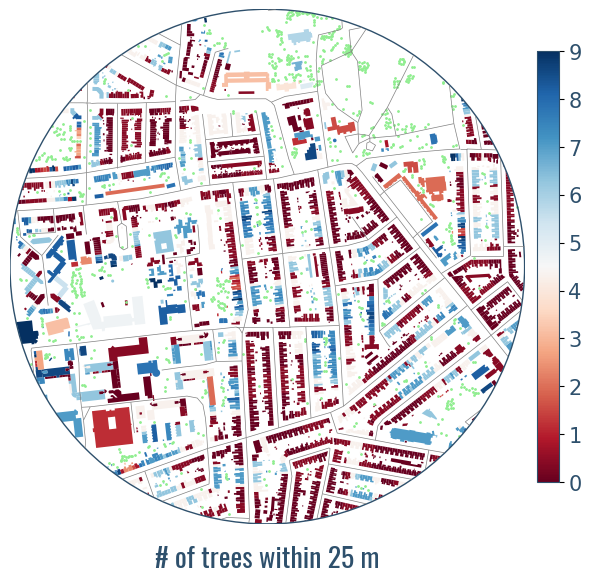

In [500]:
fig, ax = plt.subplots(figsize=(8, 8))
tree_var = 'tree_count_25m'
buildings_clip_plot = buildings_clip.plot(
    column=tree_var,
    ax=ax,
    legend=False,
    cmap='RdBu',
    edgecolor=None
)
roads_clip.plot(ax=ax, color="grey", linewidth=0.5)
trees_clip.plot(ax=ax, color="lightgreen", markersize=1)

# Set equal aspect ratio
ax.set_aspect('equal')

ax.set_xlim(center_x - zoom, center_x + zoom)
ax.set_ylim(center_y - zoom, center_y + zoom)

# Hide axes
ax.axis('off')

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

ax.set_title('# of trees within 25 m', font=font, fontsize=20, y=-0.1, color=text_colour)
norm = mpl.colors.Normalize(
    vmin=buildings_clip[tree_var].min(),
    vmax=buildings_clip[tree_var].max()
)
sm = mpl.cm.ScalarMappable(cmap='RdBu', norm=norm)
sm._A = []

# Create the vertical colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.outline.set_edgecolor(text_colour)
# Style the tick labels on the y-axis
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)

# plt.savefig("../images/poster_3.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()


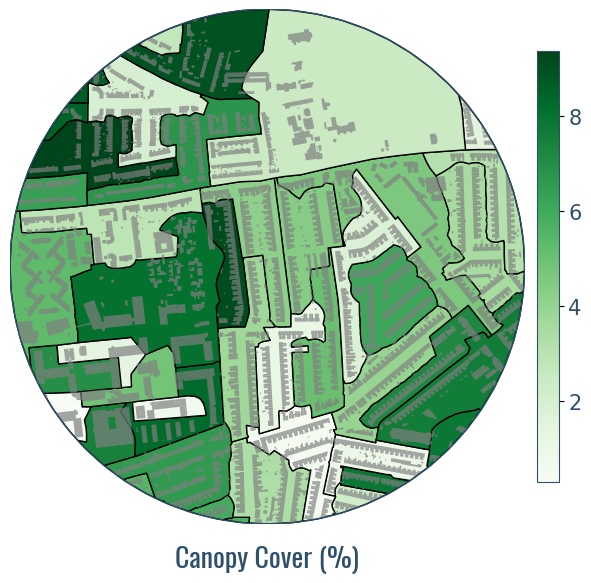

In [501]:
tree_var = 'canopy_cover'
fig, ax = plt.subplots(figsize=(8, 8))
boundary_clip = gpd.clip(t30_boundary_gdf, circle_gdf)
boundary_clip_plot = boundary_clip.plot(
    column=tree_var,
    ax=ax,
    legend=False,
    cmap='Greens',
    edgecolor='black',
    linewidth=1
)
buildings_clip.plot(
    ax=ax,
    legend=False,
    color='grey',
    edgecolor=None,
    alpha=0.7
)

# Set equal aspect ratio
ax.set_aspect('equal')

ax.set_xlim(center_x - zoom, center_x + zoom)
ax.set_ylim(center_y - zoom, center_y + zoom)

# Hide axes
ax.axis('off')

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

ax.set_title('Canopy Cover (%)', font=font, fontsize=20, y=-0.1, color=text_colour)
norm = mpl.colors.Normalize(
    vmin=boundary_clip[tree_var].min(),
    vmax=boundary_clip[tree_var].max()
)
sm = mpl.cm.ScalarMappable(cmap='Greens', norm=norm)
sm._A = []

# Create the vertical colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.outline.set_edgecolor(text_colour)
# Style the tick labels on the y-axis
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)

plt.savefig("../images/poster_30.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()


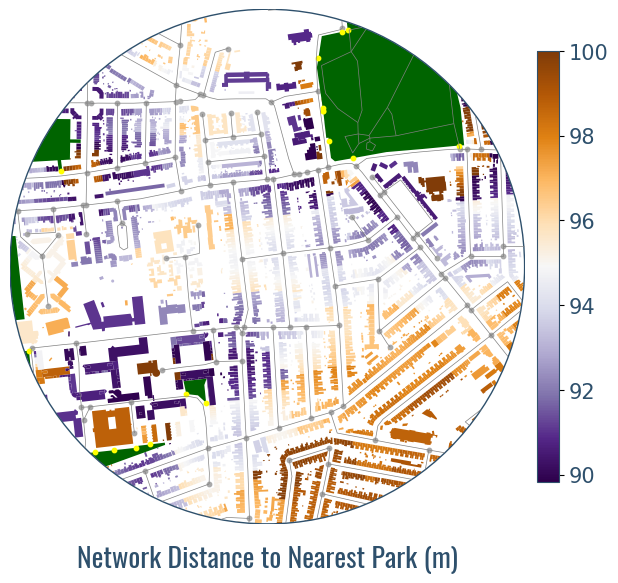

In [502]:
fig, ax = plt.subplots(figsize=(8, 8))
tree_var = 'distance_manhattan'
buildings_clip_plot = buildings_clip.plot(
    column=tree_var,
    ax=ax,
    legend=False,
    cmap='PuOr_r',
    edgecolor=None
)
roads_clip.plot(ax=ax, color="grey", linewidth=0.5)
nodes_clip.plot(ax=ax, color="darkgrey", markersize=10)
parks_clip.plot(ax=ax, color="darkgreen")
parks_access_clip.plot(ax=ax, color="yellow", markersize=10)

# Set equal aspect ratio
ax.set_aspect('equal')

ax.set_xlim(center_x - zoom, center_x + zoom)
ax.set_ylim(center_y - zoom, center_y + zoom)

# Hide axes
ax.axis('off')

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

ax.set_title('Network Distance to Nearest Park (m)', font=font, fontsize=20, y=-0.1, color=text_colour)
norm = mpl.colors.Normalize(
    vmin=buildings_clip[tree_var].min(),
    vmax=buildings_clip[tree_var].max()
)
sm = mpl.cm.ScalarMappable(cmap='PuOr_r', norm=norm)
sm._A = []

# Create the vertical colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.outline.set_edgecolor(text_colour)
# Style the tick labels on the y-axis
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)

plt.savefig("../images/poster_300.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()

In [114]:
setup_gee()

In [277]:
shape_type = 'polygon'
geom_coords = geo_boundary_gdf.to_crs("EPSG:4326").geometry.iloc[0].exterior.coords.xy if shape_type == 'polygon' else gpd.GeoSeries(circle_geom, crs=PROJECT_CRS).to_crs("EPSG:4326").geometry.iloc[0].exterior.coords.xy
pol_coords = [[x, y] for x, y in zip(*geom_coords)]
geo_boundary_fc = ee.Geometry.Polygon(pol_coords)

In [293]:
imagery_ee_path = 'COPERNICUS/S2_HARMONIZED'
start_date = '2024-01-01'
end_date = '2024-12-31'
cloud_coverage = 10.0
spectral_indexes = ['NDVI', 'NDWI', 'NDBI']

imagery_ic = (ee.ImageCollection(imagery_ee_path) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_coverage)) \
        .filterBounds(geo_boundary_fc) \
        .spectralIndices(spectral_indexes).max() \
        .select(spectral_indexes))
        
ic_ds = xr.open_dataset(imagery_ic, engine="ee", scale=10, geometry=geo_boundary_fc, crs=PROJECT_CRS)
ic_ds = ic_ds.rio.set_spatial_dims(x_dim="X", y_dim="Y", inplace=True)
ic_ds

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1, X: 886, Y: 541)
Coordinates:
  * time     (time) int64 8B 0
  * X        (X) float64 7kB 5.267e+05 5.268e+05 ... 5.356e+05 5.356e+05
  * Y        (Y) float64 4kB 1.867e+05 1.867e+05 ... 1.921e+05 1.921e+05
Data variables:
    NDVI     (time, X, Y) float32 2MB ...
    NDWI     (time, X, Y) float32 2MB ...
    NDBI     (time, X, Y) float32 2MB ...
Attributes:
    crs:      EPSG:27700

In [294]:
clipped_ds = ic_ds.rio.clip(geometries=circle_gdf.geometry, drop=True)

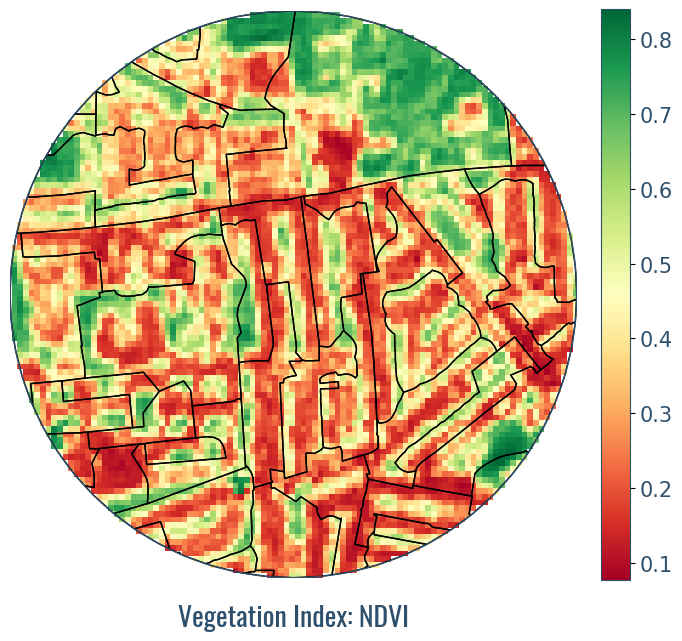

In [506]:
spectral_var = 'NDVI'

fig, ax = plt.subplots(figsize=(8, 8))

clipped_ds[spectral_var].plot(ax=ax, cmap='RdYlGn', x='X', y='Y', add_colorbar=False)
boundary_clip.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=1)
ax.set_xlim(circle_gdf.total_bounds[0], circle_gdf.total_bounds[2])
ax.set_ylim(circle_gdf.total_bounds[1], circle_gdf.total_bounds[3])
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title("")

ax.set_title(f"Vegetation Index: {spectral_var}", font=font, fontsize=20, y=-0.1, color=text_colour)
# Create a ScalarMappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=clipped_ds[spectral_var].min().values,
    vmax=clipped_ds[spectral_var].max().values
)
sm = mpl.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
sm._A = []

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

# Add a continuous colorbar at the bottom
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)

for tick in cbar.ax.xaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)
cbar.outline.set_edgecolor(text_colour)

plt.savefig("../images/poster_ndvi.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()

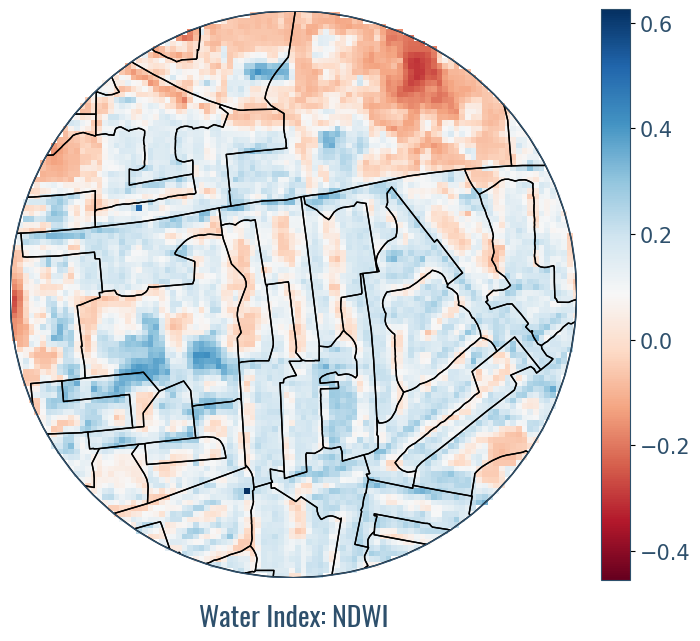

In [507]:
spectral_var = 'NDWI'
fig, ax = plt.subplots(figsize=(8, 8))

clipped_ds[spectral_var].plot(ax=ax, cmap='RdBu', x='X', y='Y', add_colorbar=False)
boundary_clip.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=1)
ax.set_xlim(circle_gdf.total_bounds[0], circle_gdf.total_bounds[2])
ax.set_ylim(circle_gdf.total_bounds[1], circle_gdf.total_bounds[3])
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title("")

ax.set_title(f"Water Index: {spectral_var}", font=font, fontsize=20, y=-0.1, color=text_colour)
# Create a ScalarMappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=clipped_ds[spectral_var].min().values,
    vmax=clipped_ds[spectral_var].max().values
)
sm = mpl.cm.ScalarMappable(cmap='RdBu', norm=norm)
sm._A = []

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

# Add a continuous colorbar at the bottom
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
for tick in cbar.ax.xaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)
cbar.outline.set_edgecolor(text_colour)

plt.savefig("../images/poster_ndwi.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()

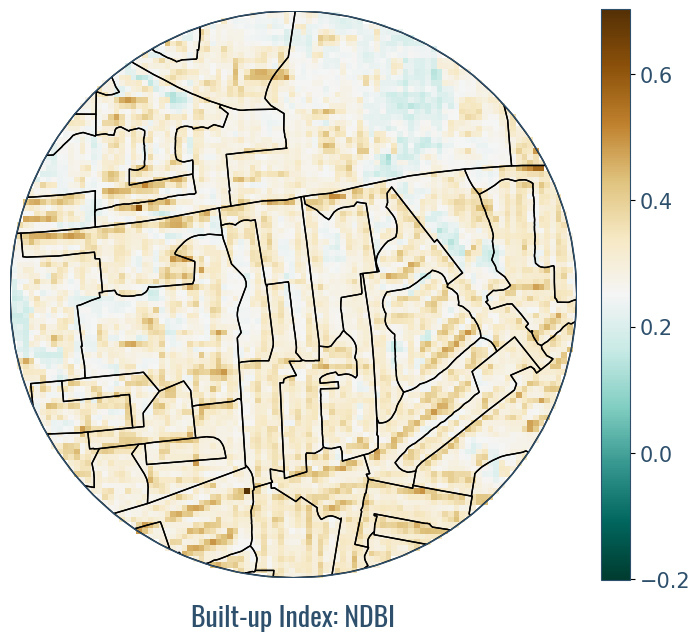

In [508]:
spectral_var = 'NDBI'
fig, ax = plt.subplots(figsize=(8, 8))

clipped_ds[spectral_var].plot(ax=ax, cmap='BrBG_r', x='X', y='Y', add_colorbar=False)
boundary_clip.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=1)
ax.set_xlim(circle_gdf.total_bounds[0], circle_gdf.total_bounds[2])
ax.set_ylim(circle_gdf.total_bounds[1], circle_gdf.total_bounds[3])
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title("")

ax.set_title(f"Built-up Index: {spectral_var}", font=font, fontsize=20, y=-0.1, color=text_colour)
# Create a ScalarMappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=clipped_ds[spectral_var].min().values,
    vmax=clipped_ds[spectral_var].max().values
)
sm = mpl.cm.ScalarMappable(cmap='BrBG_r', norm=norm)
sm._A = []

# Optional: add a white circle border for aesthetics
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=1)
ax.add_patch(circle_border)

# Add a continuous colorbar at the bottom
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
for tick in cbar.ax.xaxis.get_major_ticks():
    tick.label1.set_fontproperties(font)
cbar.ax.tick_params(labelsize=15, labelcolor=text_colour)
cbar.outline.set_edgecolor(text_colour)

plt.savefig("../images/poster_ndbi.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()

In [ ]:
photo_ic = (ee.ImageCollection(imagery_ee_path) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_coverage)) \
        .filterBounds(geo_boundary_fc) \
        .select(['B4', 'B3', 'B2']).median())
        
photo_ds = xr.open_dataset(photo_ic, engine="ee", scale=10, geometry=geo_boundary_fc, crs=PROJECT_CRS)
photo_ds = photo_ds.rio.set_spatial_dims(x_dim="X", y_dim="Y", inplace=True)
clipped_photo_ds = photo_ds.rio.clip(geometries=circle_gdf.geometry, drop=True)
photo_da = clipped_photo_ds[['B4', 'B3', 'B2']].to_array(dim='band')
photo_da

<xarray.DataArray (band: 3, time: 1, X: 100, Y: 100)> Size: 120kB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],


       [[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],


       [[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]],
      shape=(3, 1, 100, 100), dtype=float32)
Coordinates:
  * time         (time) int64 8B 0
  * X            (X) float64 800B 5.328e+05 5.328e+05 ... 5.337e+05 5.337e+05
  * Y            (Y) float64 800B 1.899e+05 1.899e+05 ... 1.909e+05 1.909e+05
    spatial_ref  int64 8B 0
  * band         (band) object 24B 'B4' 'B3' 'B2'
Attributes:
    crs:      EPSG:27700

In [482]:
geom_coords = gpd.GeoSeries(circle_geom, crs=PROJECT_CRS).to_crs("EPSG:4326").geometry.iloc[0].exterior.coords.xy
circle_coords = [[x, y] for x, y in zip(*geom_coords)]
circle_fc = ee.Geometry.Polygon(circle_coords)

In [513]:
import geemap

# Create a map centered on the geometry
Map = geemap.Map(center=[web_center_x, web_center_y], zoom=12)
Map.addLayer(photo_ic, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'RGB Median Composite')
Map.addLayer(circle_fc, {'color': text_colour}, 'Boundary')
Map


Map(center=[51.59676020442749, -0.07764447270431617], controls=(WidgetControl(options=['position', 'transparen…

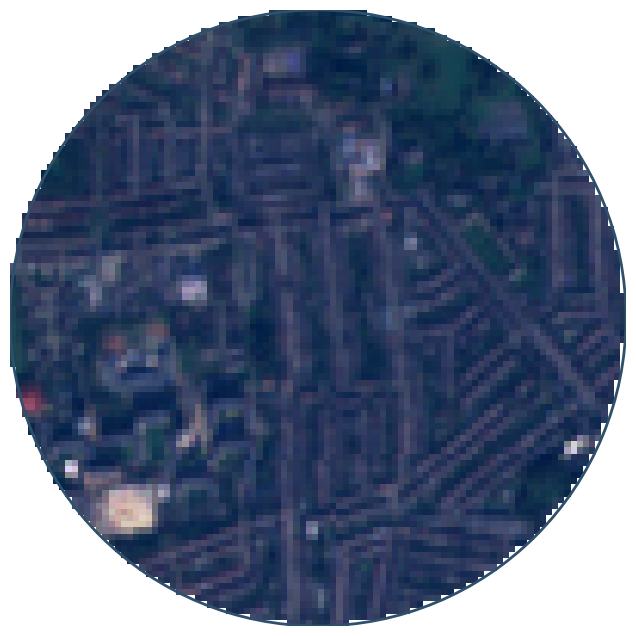

In [510]:
def normalize_array(arr):
    """Normalize array to 0-1 range for plotting"""
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min)

# Apply normalization to each band
photo_normalized = normalize_array(photo_da.isel(time=0))
photo_normalized = photo_normalized.sel(Y=photo_normalized.Y[::-1])

fig, ax = plt.subplots(figsize=(8, 8))

# Transpose to (Y, X, band) and plot on the given ax
ax.imshow(photo_normalized.transpose('Y', 'X', 'band'))
ax.set_axis_off()  # Remove axes for cleaner look
# Optional: add a white circle border for aesthetics

circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=2)
ax.add_patch(circle_border)

plt.savefig("../images/poster_sentinel_rgb.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()


In [429]:
# Define the WMS URL and layer
rgb_wms_url = "http://digimap.edina.ac.uk/mapproxy/wms/aerial-licensed/22eef59f8b1a93c189669bc9be2909a771b55c070f112983cc0e27cc5d25d083?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetCapabilities"

rgb_wms = WebMapService(rgb_wms_url, version="1.3.0")
# Get the WMS image
rgb_img = rgb_wms.getmap(layers=['aerial_rgb25cm'],
                 srs=PROJECT_CRS,
                 bbox=circle_gdf.total_bounds,
                 size=(1000, 1000),
                 format='image/png',
                 transparent=True)

# Read the image data
rgb_img_data = Image.open(BytesIO(rgb_img.read()))
output_image_path = "../images/poster_aerial.png"
rgb_img_data.save(output_image_path, "PNG")

In [452]:
rgb_img_data_np =np.array(rgb_img_data)
rgb_img_data_np.shape

(1000, 1000, 4)

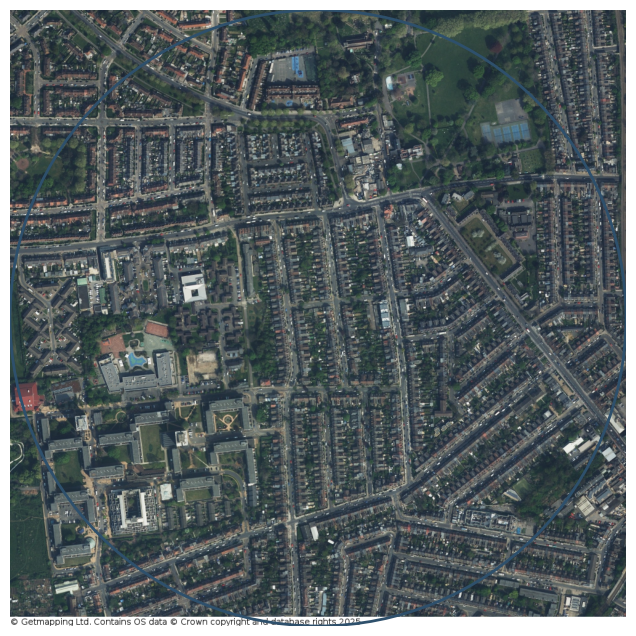

In [511]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_img_data_np)
ax.set_axis_off()
# --- Create circular mask in Axes coordinates ---
circle = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                facecolor='none', edgecolor='none')
ax.set_clip_path(circle)

# Optional: add visible circle border
circle_border = Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                       facecolor='none', edgecolor=text_colour, linewidth=2)
ax.add_patch(circle_border)

plt.show()

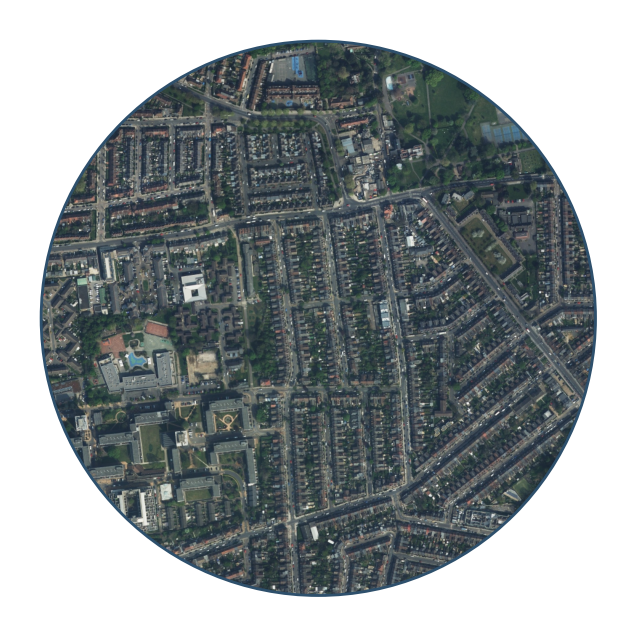

In [512]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Your existing code
rgb_img_data_np = np.array(rgb_img_data)
fig, ax = plt.subplots(figsize=(8, 8))

# Create circular mask
y, x = np.ogrid[:rgb_img_data_np.shape[0], :rgb_img_data_np.shape[1]]
center_x, center_y = rgb_img_data_np.shape[1] // 2, rgb_img_data_np.shape[0] // 2
radius = min(center_x, center_y) * 0.9  # 90% of half the smallest dimension

# Create distance from center for each pixel
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# Create mask (True inside circle, False outside)
mask = dist_from_center <= radius

# Apply mask to image data
masked_img = rgb_img_data_np.copy()
masked_img[~mask] = 0  # Set pixels outside circle to black/transparent

# Display the masked image
ax.imshow(masked_img)
ax.set_axis_off()

# Optional: add visible circle border
circle_border = Circle((center_x, center_y), radius, 
                       facecolor='none', edgecolor=text_colour, linewidth=2)
ax.add_patch(circle_border)

plt.savefig("../images/poster_aerial_rgb.png", bbox_inches='tight', transparent=True, dpi=300)

plt.show()